# Lamellar grating diffraction efficiency

Calculation of the diffraction efficiency for a lamellar grating, as a function of photon energy, using `Blazr.m`'s VLS trajectory and lamellar-grating efficiency solvers.

This uses the [`xreticolo`](https://pypi.org/project/xreticolo/) package, which wraps `Blazr.m` and shells out to `octave-cli` under the hood (no MATLAB license required).

awojdyla@lbl.gov -- October 2021 (ported to Python August 2026)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import xreticolo as xr

## Grating and beamline parameters

In [2]:
# grating groove density
g_lpm = 179e3
cff = 1.632
thickness_m = 19e-9
duty_cycle = 0.38
material = "Au"

# VLS parameters
E_opt_eV = 806
pv_m = 24.301
qv_m = 7.573

# diffraction order
order = 1

## Energy sweep

For each photon energy: get the incidence angle from the VLS trajectory, then compute the +1 order diffraction efficiency of the lamellar grating at that angle.

Each `vls_trajectory`/`efficiency_lamellarx` call launches a short-lived Octave process, so this cell takes roughly a second per energy point.

In [3]:
Es_eV = np.linspace(250, 2500, 21)
eta1s = np.zeros_like(Es_eV)

for i, E_eV in enumerate(Es_eV):
    alpha_rad, beta_rad, theta_rad = xr.vls_trajectory(E_eV, E_opt_eV, g_lpm, pv_m, qv_m, cff)
    eta1s[i] = xr.efficiency_lamellarx(
        g_lpm, thickness_m, E_eV, np.pi / 2 - alpha_rad, material, duty_cycle, order
    )

eta1s

array([0.16434471, 0.20517791, 0.22780777, 0.2348666 , 0.23674131,
       0.23501267, 0.23081062, 0.21990941, 0.19844078, 0.16764312,
       0.13950175, 0.11599162, 0.09791286, 0.08777409, 0.08148703,
       0.06922194, 0.05409211, 0.06381413, 0.0345112 , 0.03014833,
       0.03501516])

## Plot

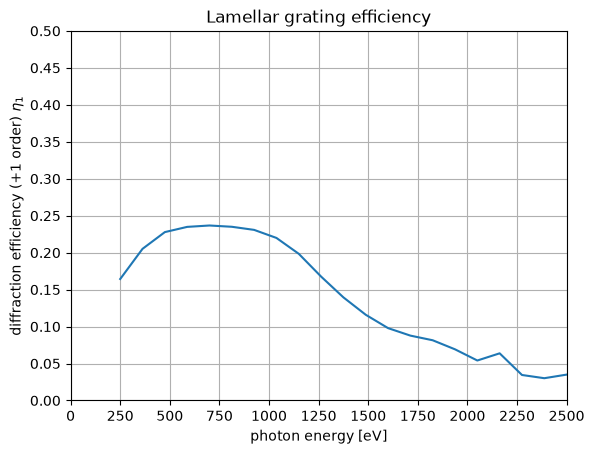

In [4]:
fig, ax = plt.subplots()
ax.plot(Es_eV, eta1s)
ax.set_title("Lamellar grating efficiency")
ax.set_xlabel("photon energy [eV]")
ax.set_ylabel(r"diffraction efficiency (+1 order) $\eta_1$")

ax.set_xlim(250, 2500)
ax.set_xticks(np.arange(0, 2501, 250))

ax.set_ylim(0, 0.5)
ax.set_yticks(np.arange(0, 0.51, 0.05))
ax.grid(True)

plt.show()